# 07 - Strategic Dataset Training

Train baseline transformer on strategically filtered discard dataset.

Dataset:
- discard/strategic.db

Goal:
- evaluate effect of removing trivial states
- compare strategic metrics
- analyze policy quality changes

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import torch

from torch.utils.data import DataLoader

from tqdm import tqdm

In [3]:
from src.data.dataset import (
    MahjongDataset
)

from src.data.collator import (
    MahjongCollator
)

from src.models.transformer_model import (
    MahjongTransformer
)

In [4]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
train_dataset = MahjongDataset(
    db_path="../data/discard/strategic.db",

    limit=500000,
)

In [6]:
collator = MahjongCollator()

In [7]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    collate_fn=collator.collate,

    num_workers=4,

    pin_memory=True,
)

In [8]:
model = MahjongTransformer(

    embedding_dim=128,

    num_heads=8,

    num_layers=4,

    ff_dim=512,
).to(device)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [10]:
CHECKPOINT_PATH = (
    "../checkpoints/strategic_500k/epoch_8.pt"
)

checkpoint = torch.load(

    CHECKPOINT_PATH,

    map_location=device,
)

model.load_state_dict(

    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(

    checkpoint["optimizer_state_dict"]
)

start_epoch = checkpoint["epoch"]

print(
    f"Loaded epoch {start_epoch}"
)

Loaded epoch 8


In [11]:
NUM_EPOCHS = 15

In [12]:
print(
    f"Resuming from epoch {start_epoch}"
)

print(
    f"Training until epoch {NUM_EPOCHS}"
)

Resuming from epoch 8
Training until epoch 15


In [13]:
train_losses = []

train_accuracies = []

for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    progress_bar = tqdm(train_loader)

    for batch in progress_bar:

        # ============================================
        # MOVE BATCH TO DEVICE
        # ============================================

        moved = {}

        for key, value in batch.items():

            if isinstance(value, list):

                moved[key] = [
                    v.to(device)
                    for v in value
                ]

            elif torch.is_tensor(value):

                moved[key] = value.to(device)

            else:

                moved[key] = value

        batch = moved

        # ============================================
        # ZERO GRAD
        # ============================================

        optimizer.zero_grad()

        # ============================================
        # FORWARD
        # ============================================

        logits_list = model(batch)

        # ============================================
        # LOSS
        # ============================================

        losses = []

        predictions = []

        for i, logits in enumerate(logits_list):

            target = batch[
                "target"
            ][i]

            loss = torch.nn.functional.cross_entropy(

                logits.unsqueeze(0),

                target.unsqueeze(0),
            )

            losses.append(loss)

            prediction = torch.argmax(
                logits
            )

            predictions.append(
                prediction
            )

        batch_loss = torch.stack(
            losses
        ).mean()

        # ============================================
        # BACKPROP
        # ============================================

        batch_loss.backward()

        optimizer.step()

        # ============================================
        # METRICS
        # ============================================

        total_loss += batch_loss.item()

        predictions = torch.stack(
            predictions
        )

        correct = (
            predictions
            ==
            batch["target"]
        ).sum().item()

        total_correct += correct

        total_samples += len(
            predictions
        )

        # ============================================
        # PROGRESS BAR
        # ============================================

        progress_bar.set_description(

            f"Epoch {epoch+1} | "
            f"Loss {batch_loss.item():.4f}"
        )

    # ================================================
    # EPOCH METRICS
    # ================================================

    train_loss = (
        total_loss
        /
        len(train_loader)
    )

    train_accuracy = (
        total_correct
        /
        total_samples
    )

    print()

    print(
        f"Epoch {epoch+1}"
    )

    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    checkpoint_path = (

        f"../checkpoints/strategic_500k/"
        f"epoch_{epoch+1}.pt"
    )

    torch.save({

        "epoch":
            epoch + 1,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "train_accuracy":
            train_accuracy,

    }, checkpoint_path)

    print(
        f"Saved checkpoint: "
        f"{checkpoint_path}"
    )

    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

Epoch 9 | Loss 1.2158: 100%|██████████| 7813/7813 [57:00<00:00,  2.28it/s] 



Epoch 9
Train Loss: 0.9791
Train Accuracy: 0.6477
Saved checkpoint: ../checkpoints/strategic_500k/epoch_9.pt


Epoch 10 | Loss 0.9561: 100%|██████████| 7813/7813 [56:26<00:00,  2.31it/s]  



Epoch 10
Train Loss: 0.9654
Train Accuracy: 0.6510
Saved checkpoint: ../checkpoints/strategic_500k/epoch_10.pt


Epoch 11 | Loss 0.8745: 100%|██████████| 7813/7813 [56:06<00:00,  2.32it/s]  


...


Epoch 13
Train Loss: 0.9314
Train Accuracy: 0.6610
Saved checkpoint: ../checkpoints/strategic_500k/epoch_13.pt


Epoch 14 | Loss 0.8475: 100%|██████████| 7813/7813 [52:12<00:00,  2.49it/s]  



Epoch 14
Train Loss: 0.9220
Train Accuracy: 0.6635
Saved checkpoint: ../checkpoints/strategic_500k/epoch_14.pt


Epoch 15 | Loss 0.8476: 100%|██████████| 7813/7813 [53:43<00:00,  2.42it/s]  


Epoch 15
Train Loss: 0.9132
Train Accuracy: 0.6668
Saved checkpoint: ../checkpoints/strategic_500k/epoch_15.pt


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
history_df = pd.DataFrame({

    "epoch": list(
        range(
            start_epoch + 1,
            NUM_EPOCHS + 1
        )
    ),

    "train_loss":
        train_losses,

    "train_accuracy":
        train_accuracies,
})
plt.savefig(

    "../reports/figures/strategic_distribution_500k_15.png",

    dpi=300,

    bbox_inches="tight",
)

history_df

,epoch,train_loss,train_accuracy
0,9,0.979067,0.647656
1,10,0.965440,0.651020
2,11,0.952509,0.654694
3,12,0.941509,0.658144
4,13,0.931434,0.660984
5,14,0.922000,0.663530
6,15,0.913199,0.666802


<Figure size 640x480 with 0 Axes>

In [19]:
sns.set_theme(
    style="whitegrid"
)

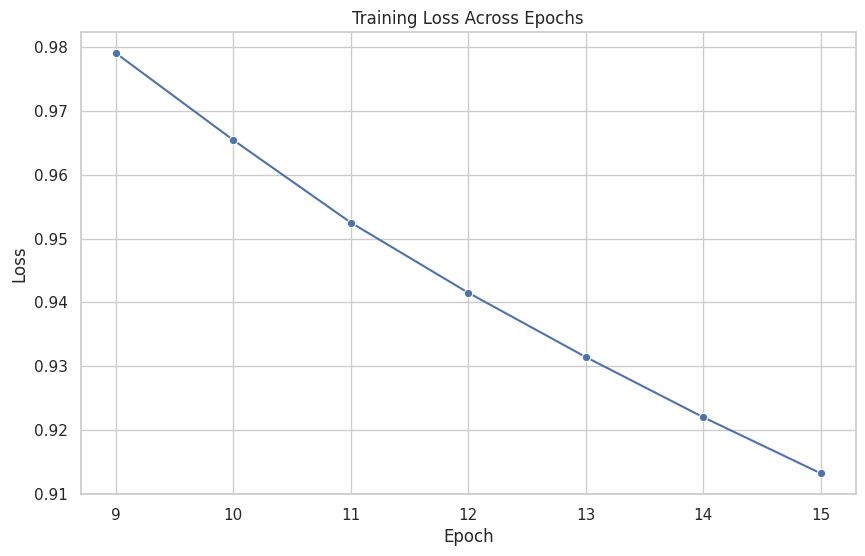

In [20]:
plt.figure(figsize=(10, 6))

sns.lineplot(

    data=history_df,

    x="epoch",

    y="train_loss",

    marker="o",
)

plt.title(
    "Training Loss Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.savefig(

    "../reports/figures/strategic_loss_500k_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

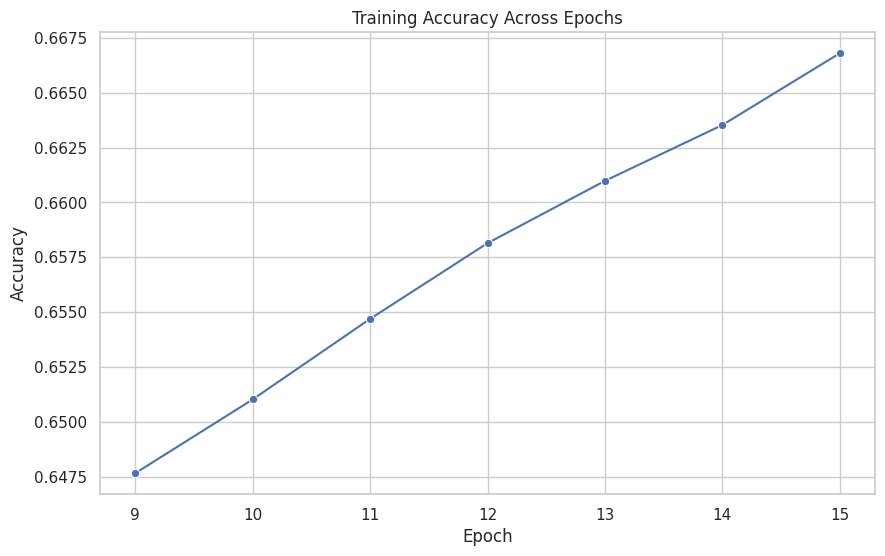

In [21]:
plt.figure(figsize=(10, 6))

sns.lineplot(

    data=history_df,

    x="epoch",

    y="train_accuracy",

    marker="o",
)

plt.title(
    "Training Accuracy Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.savefig(

    "../reports/figures/strategic_accuracy_500k_15.png",

    dpi=300,

    bbox_inches="tight",
)

plt.show()

In [22]:
history_long = pd.melt(

    history_df,

    id_vars="epoch",

    value_vars=[
        "train_loss",
        "train_accuracy",
    ],

    var_name="metric",

    value_name="value",
)

history_long.head()

,epoch,metric,value
0,9,train_loss,0.979067
1,10,train_loss,0.965440
2,11,train_loss,0.952509
3,12,train_loss,0.941509
4,13,train_loss,0.931434


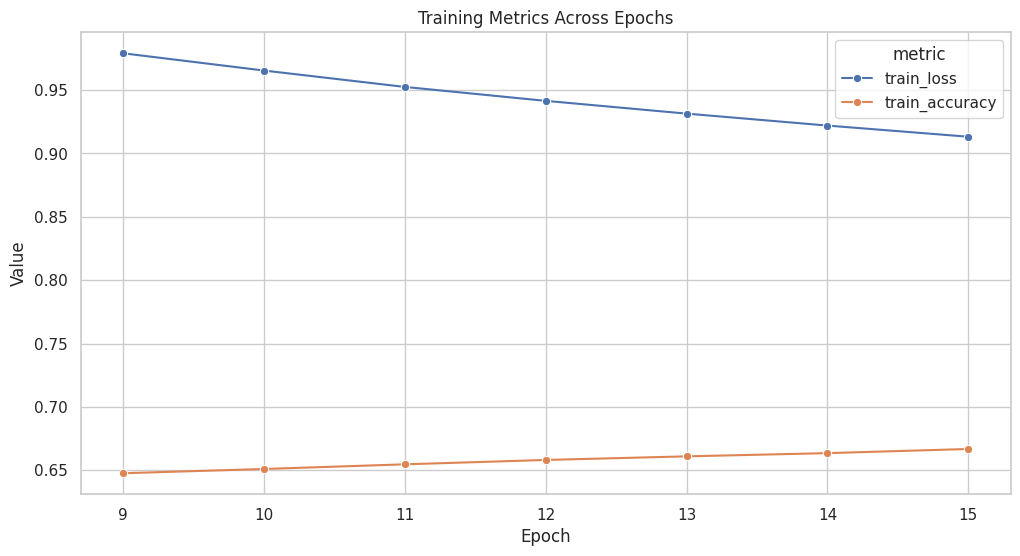

In [23]:
plt.figure(figsize=(12, 6))

sns.lineplot(

    data=history_long,

    x="epoch",

    y="value",

    hue="metric",

    marker="o",
)

plt.title(
    "Training Metrics Across Epochs"
)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.savefig(

    "../reports/figures/strategic_metrics_500k_15.png",

    dpi=300,
)

plt.show()